In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# DE10YT

In [43]:
df_bund = pd.read_excel('./Dataset/Macro/DE10YT=RR.xlsx')
df_bund['Date'] = pd.to_datetime(df_bund['Date'], errors='coerce')

analysis_columns = ['Bid', 'Ask', 'BidYld', 'AskYld']
df_plot = df_bund.dropna(subset=analysis_columns).sort_values('Date')

df_numeric = df_plot[analysis_columns]
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

             Bid       Ask    BidYld    AskYld
Bid     1.000000  0.999239 -0.187696 -0.188421
Ask     0.999239  1.000000 -0.183865 -0.184763
BidYld -0.187696 -0.183865  1.000000  0.998888
AskYld -0.188421 -0.184763  0.998888  1.000000


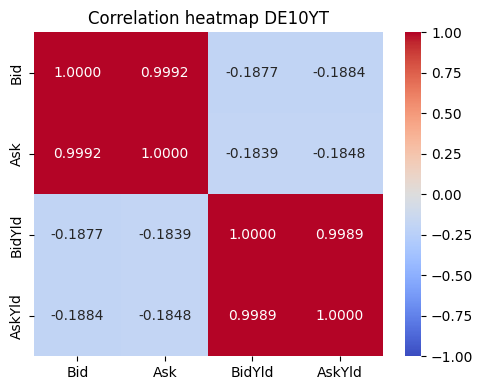

In [44]:
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation heatmap DE10YT")
plt.tight_layout()
plt.savefig('./Correlations/DE10YT.png')

In [45]:
X = df_numeric.copy()
X['Constant'] = 1 

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data[vif_data['Variable'] != 'Constant']

print("\n")
print(vif_data.to_string(index=False))



Variable        VIF
     Bid 670.213799
     Ask 669.333182
  BidYld 454.256906
  AskYld 453.995634


Correlation Values > 0.95 indicate extreme redundancy.

VIF: Values > 10 indicate critical multicollinearity.

Since all values are highly correlated, we can conclude that they are redundant and do not provide additional information to the model. Hence, we can keep only BidYld as the representative feature for the DE10YT macro feature.

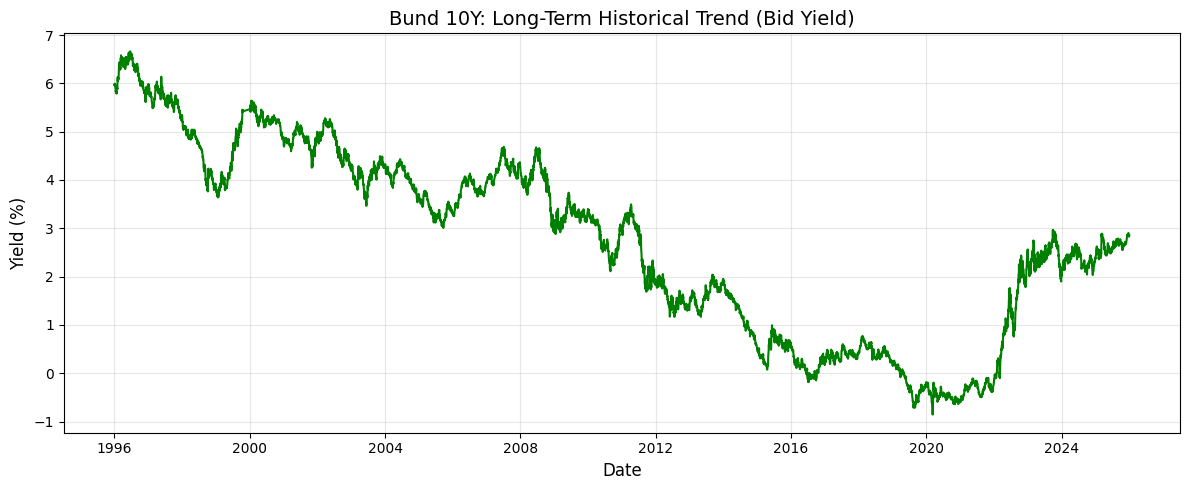

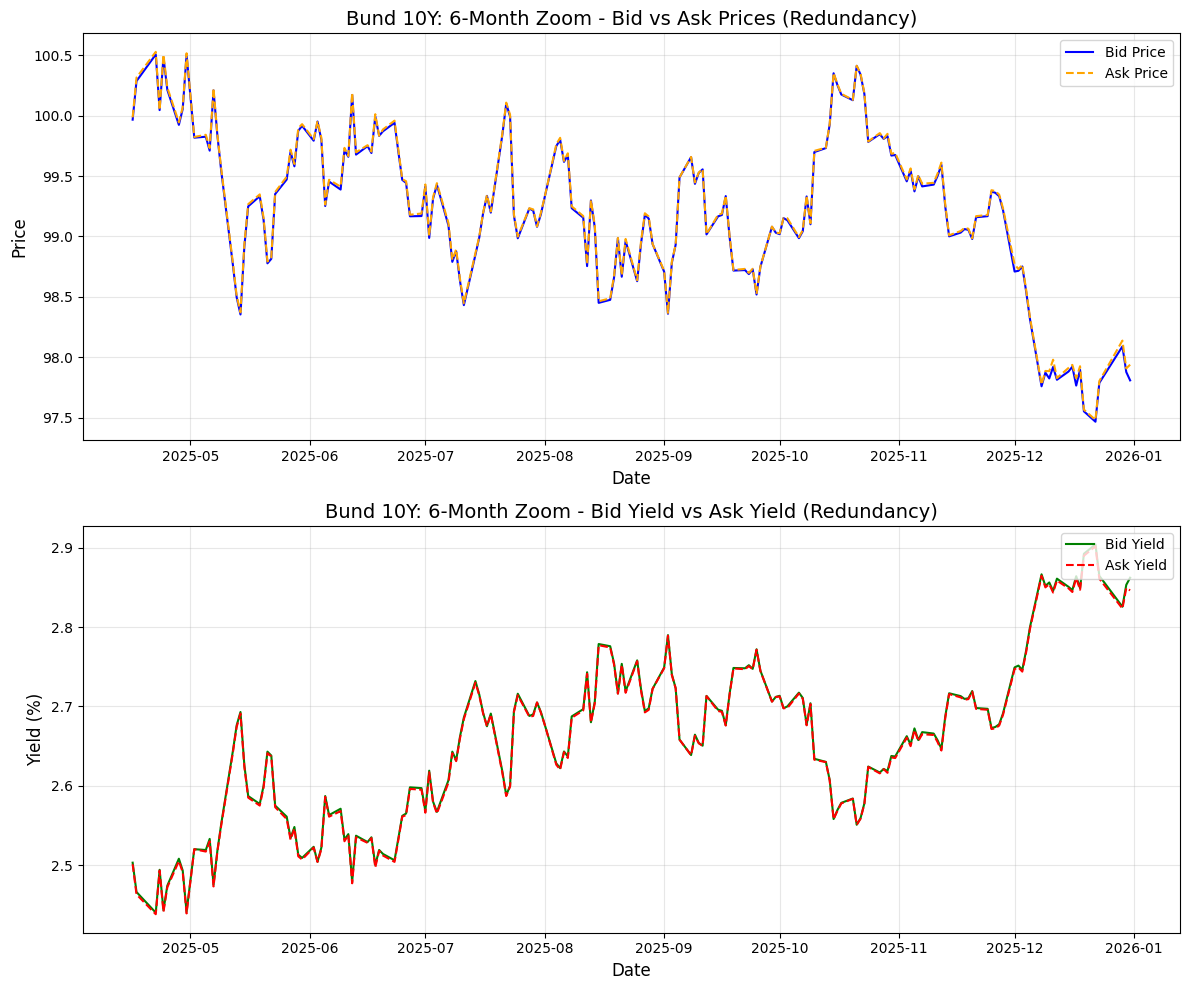

In [46]:
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_plot['Date'], df_plot['BidYld'], color='green', linewidth=1.5)
ax1.set_title('Bund 10Y: Long-Term Historical Trend (Bid Yield)', fontsize=14)
ax1.set_ylabel('Yield (%)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Plots/DE10YT_Macro.png', dpi=300)
plt.show()

# ==========================================
# PLOT 2: MICRO VIEW (6-Month Zoom to show redundancy)
# We zoom in on the last 180 days to clearly see the Bid/Ask overlap
# ==========================================
df_zoom = df_plot.tail(180)

fig2, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=False)

# Subplot A: Prices (Bid vs Ask)
axes[0].plot(df_zoom['Date'], df_zoom['Bid'], label='Bid Price', color='blue', linewidth=1.5)
axes[0].plot(df_zoom['Date'], df_zoom['Ask'], label='Ask Price', color='orange', linewidth=1.5, linestyle='--')
axes[0].set_title('Bund 10Y: 6-Month Zoom - Bid vs Ask Prices (Redundancy)', fontsize=14)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Subplot B: Yields (BidYld vs AskYld)
axes[1].plot(df_zoom['Date'], df_zoom['BidYld'], label='Bid Yield', color='green', linewidth=1.5)
axes[1].plot(df_zoom['Date'], df_zoom['AskYld'], label='Ask Yield', color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Bund 10Y: 6-Month Zoom - Bid Yield vs Ask Yield (Redundancy)', fontsize=14)
axes[1].set_ylabel('Yield (%)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./Plots/DE10YT_Micro.png', dpi=300)
plt.show()

# EUR

In [47]:
df_eur = pd.read_excel('./Dataset/Macro/EUR=.xlsx')
df_eur = df_eur.rename(columns={'Exchange Date': 'Date'})
df_eur['Date'] = pd.to_datetime(df_eur['Date'], errors='coerce')

analysis_columns = ['Bid', 'Ask', 'High', 'Low', 'Open', 'Refresh Rate', 'BidNet']
df_plot = df_eur.dropna(subset=['Bid', 'Ask', 'High', 'Low', 'Open']).sort_values('Date')
df_numeric = df_eur[analysis_columns].dropna()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce').dropna()

In [48]:
X = df_numeric.copy()
X['Constant'] = 1

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

vif_data = vif_data[vif_data['Variable'] != 'Constant']
print(vif_data.to_string(index=False))

    Variable           VIF
         Bid 770563.737958
         Ask 751991.083738
        High   2204.822428
         Low   2202.511389
        Open  15627.545534
Refresh Rate      1.027663
      BidNet     42.048287


Refresh rate shows a low VIF value, indicating that it is not highly correlated with the other features. This suggests that it may provide unique information to the model and can be retained as a valuable feature for analysis.

All the other features (Bid, Ask, High, Low, Open, BidNet) have VIF values greater than 10, indicating that they are highly correlated with each other and may cause multicollinearity issues in the model. Therefore, it is advisable to drop these features and keep only Bid among them.

                   Bid       Ask      High       Low      Open  Refresh Rate  \
Bid           1.000000  0.999999  0.999311  0.999318  0.998498     -0.104357   
Ask           0.999999  1.000000  0.999312  0.999315  0.998496     -0.104393   
High          0.999311  0.999312  1.000000  0.999067  0.999322     -0.101680   
Low           0.999318  0.999315  0.999067  1.000000  0.999313     -0.106837   
Open          0.998498  0.998496  0.999322  0.999313  1.000000     -0.104185   
Refresh Rate -0.104357 -0.104393 -0.101680 -0.106837 -0.104185      1.000000   
BidNet        0.027521  0.027537  0.000236  0.000545 -0.026630     -0.003551   

                BidNet  
Bid           0.027521  
Ask           0.027537  
High          0.000236  
Low           0.000545  
Open         -0.026630  
Refresh Rate -0.003551  
BidNet        1.000000  


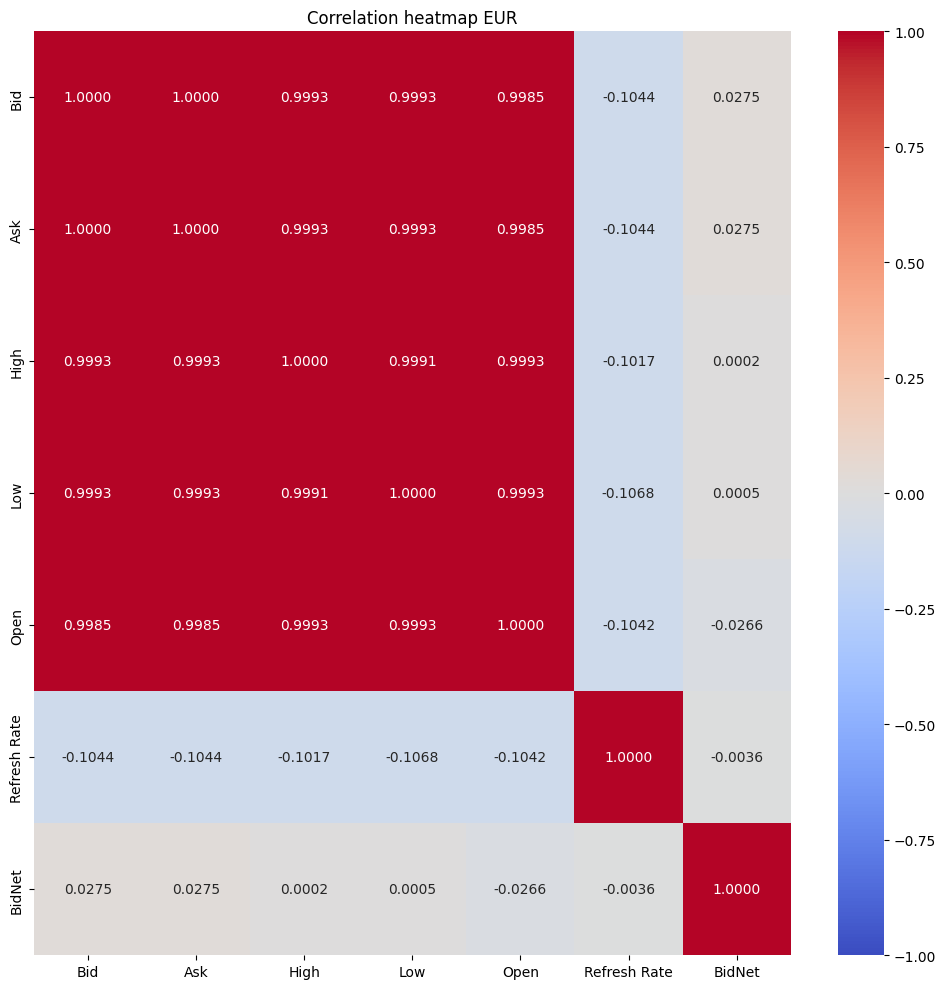

In [49]:
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation heatmap EUR")
plt.tight_layout()
plt.savefig('./Correlations/EUR.png')

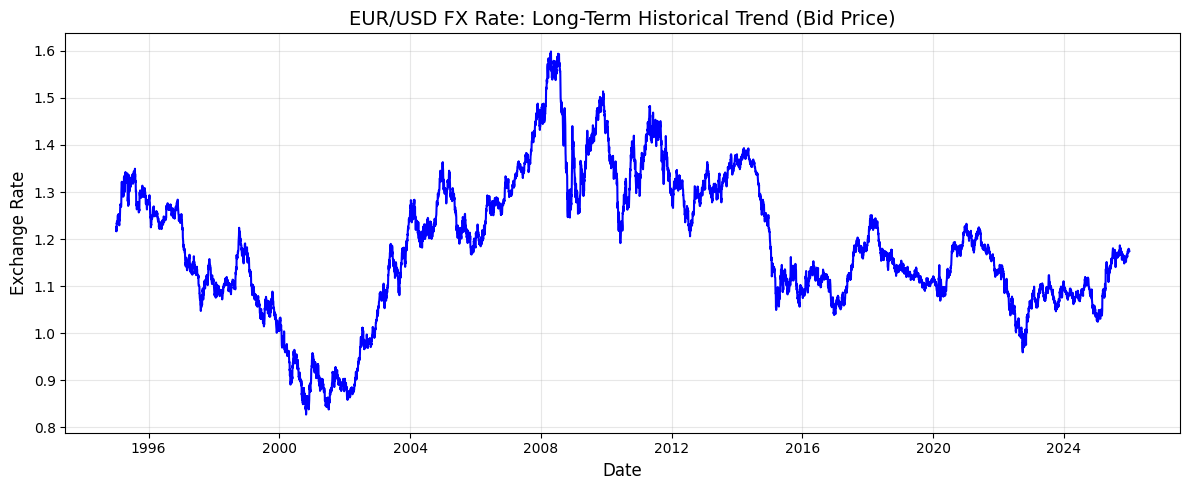

In [50]:
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_plot['Date'], df_plot['Bid'], color='blue', linewidth=1.5)
ax1.set_title('EUR/USD FX Rate: Long-Term Historical Trend (Bid Price)', fontsize=14)
ax1.set_ylabel('Exchange Rate', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Plots/EURUSD_Macro.png', dpi=300)
plt.show()

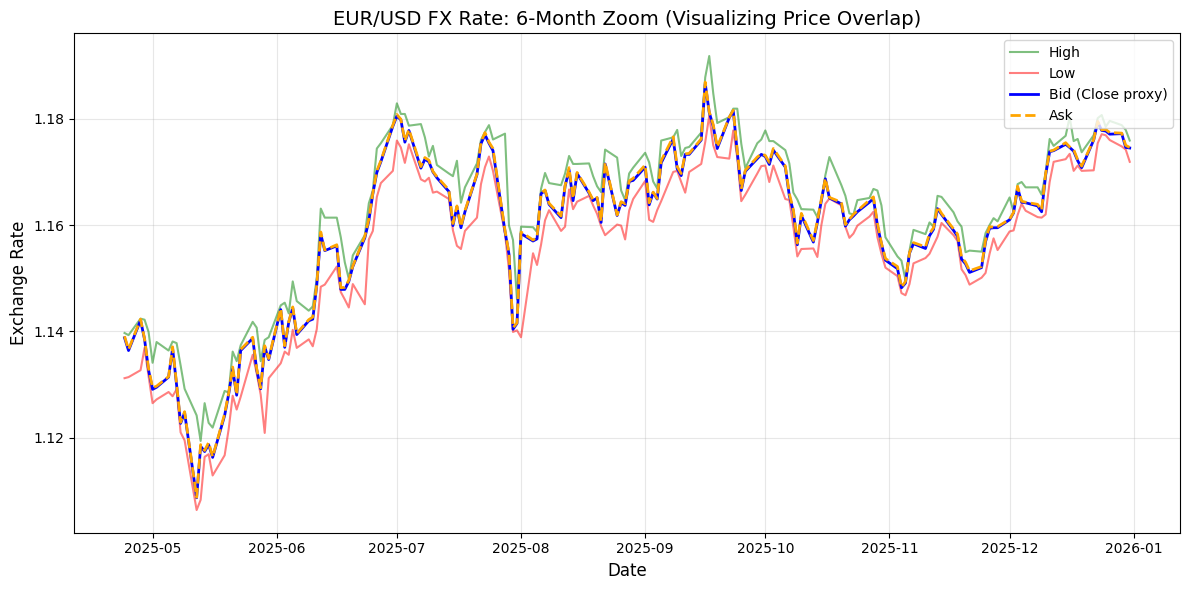

In [51]:
df_zoom = df_plot.tail(180)

# Using a single subplot because all prices share the exact same scale
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Plot High and Low with semi-transparency (alpha=0.4) to show the "corridor"
ax2.plot(df_zoom['Date'], df_zoom['High'], label='High', color='green', linewidth=1.5, alpha=0.5)
ax2.plot(df_zoom['Date'], df_zoom['Low'], label='Low', color='red', linewidth=1.5, alpha=0.5)

# Plot Bid and Ask. Ask is dashed to highlight the perfect overlap
ax2.plot(df_zoom['Date'], df_zoom['Bid'], label='Bid (Close proxy)', color='blue', linewidth=2)
ax2.plot(df_zoom['Date'], df_zoom['Ask'], label='Ask', color='orange', linewidth=2, linestyle='--')

ax2.set_title('EUR/USD FX Rate: 6-Month Zoom (Visualizing Price Overlap)', fontsize=14)
ax2.set_ylabel('Exchange Rate', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./Plots/EURUSD_Micro.png', dpi=300)
plt.show()

# FTMIB

In [52]:
df_ftmib = pd.read_excel('./Dataset/Macro/FTMIB.xlsx')
df_ftmib = df_ftmib.rename(columns={'Exchange Date': 'Date'})
df_ftmib['Date'] = pd.to_datetime(df_ftmib['Date'], errors='coerce')

analysis_columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df_plot = df_ftmib.dropna(subset=['Close', 'High', 'Low', 'Open']).sort_values('Date')
df_numeric = df_ftmib[analysis_columns].dropna()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce').dropna()

In [53]:
X = df_numeric.copy()
X['Constant'] = 1 

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Remove the constant for printing purposes
vif_data = vif_data[vif_data['Variable'] != 'Constant']
print(vif_data.to_string(index=False))

Variable         VIF
   Close 5248.080622
    High 6017.339590
     Low 5466.205532
    Open 5237.021391
  Volume    1.285846


Price metrics (Close, High, Low, Open) show extreme VIFs (thousands) confirming perfect multicollinearity. Only the 'Close' price" should be kept as the official daily market proxy.
'Volume' shows a very low VIF (near 1.0). Since it measures the quantity of shares traded rather than their price, it provides independent and highly valuable information for the LSTM.

           Close      High       Low      Open    Volume
Close   1.000000  0.999672  0.999757  0.999422 -0.220377
High    0.999672  1.000000  0.999545  0.999769 -0.213476
Low     0.999757  0.999545  1.000000  0.999654 -0.226019
Open    0.999422  0.999769  0.999654  1.000000 -0.218627
Volume -0.220377 -0.213476 -0.226019 -0.218627  1.000000


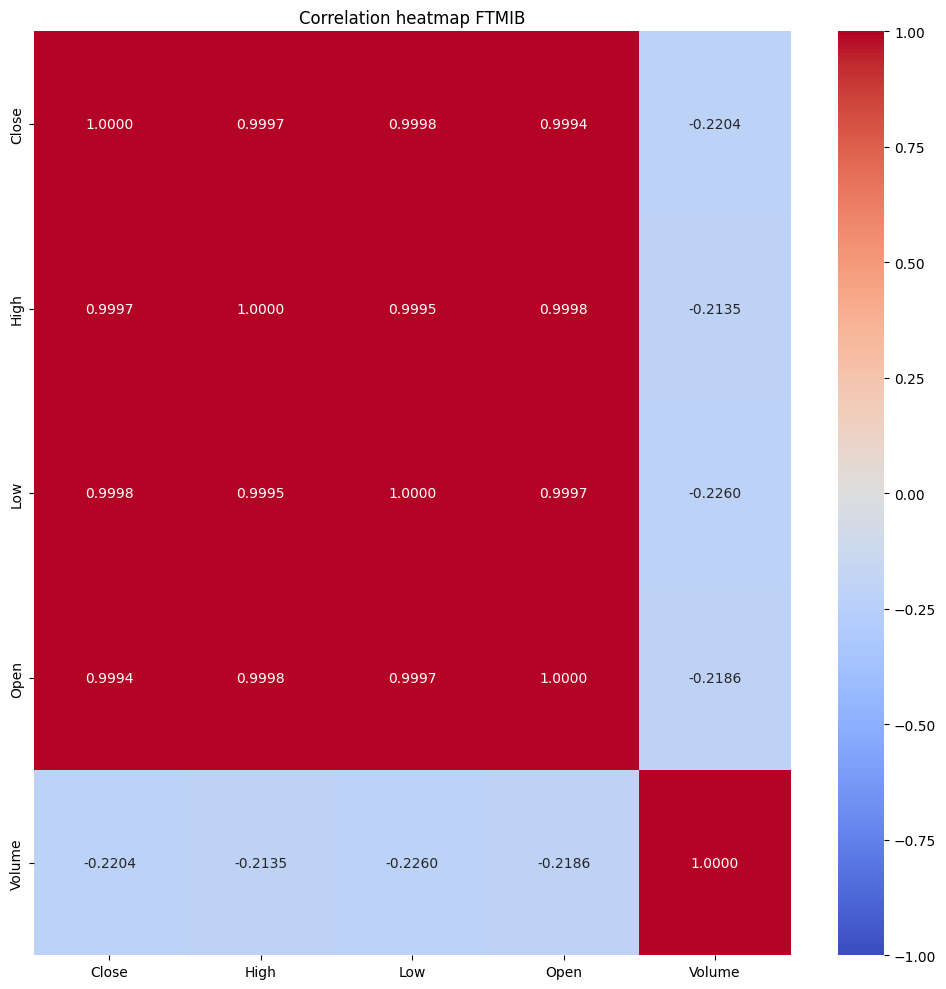

In [54]:
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation heatmap FTMIB")
plt.tight_layout()
plt.savefig('./Correlations/FTMIB.png')

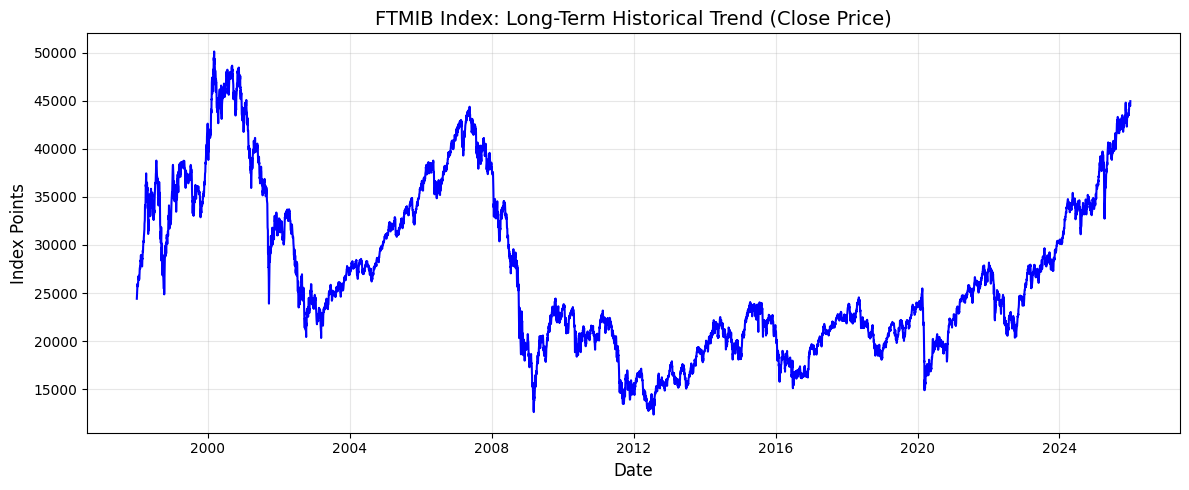

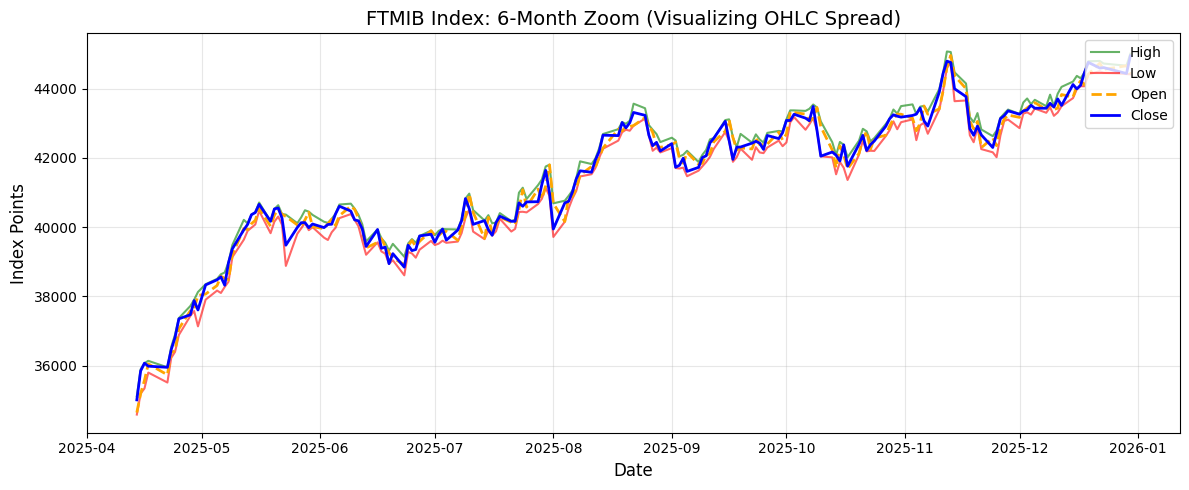

In [55]:
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df_plot['Date'], df_plot['Close'], color='blue', linewidth=1.5)
ax1.set_title('FTMIB Index: Long-Term Historical Trend (Close Price)', fontsize=14)
ax1.set_ylabel('Index Points', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Plots/FTMIB.png', dpi=300)
plt.show()

df_zoom = df_plot.tail(180)
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(df_zoom['Date'], df_zoom['High'], label='High', color='green', linewidth=1.5, alpha=0.6)
ax2.plot(df_zoom['Date'], df_zoom['Low'], label='Low', color='red', linewidth=1.5, alpha=0.6)

ax2.plot(df_zoom['Date'], df_zoom['Open'], label='Open', color='orange', linewidth=2, linestyle='--')
ax2.plot(df_zoom['Date'], df_zoom['Close'], label='Close', color='blue', linewidth=2)

ax2.set_title('FTMIB Index: 6-Month Zoom (Visualizing OHLC Spread)', fontsize=14)
ax2.set_ylabel('Index Points', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Plots/FTMIB_6Months.png', dpi=300)
plt.show()